# 02 濾波與降噪

在理解影像資料表示之後，Filtering 是第一個真正進入影像前處理的步驟。

目標不是單純「讓影像變平滑」。真正要問的是：

```text
當我移除雜訊時，我同時破壞了哪些有用細節？
```

## 1. 目標

這份 notebook 比較三種實用濾波方法：

- Gaussian Blur
- Median Filter
- Bilateral Filter

並且會在兩種常見雜訊下測試：

- Gaussian noise
- Salt-and-pepper noise

重點放在視覺比較、局部放大、差異圖、簡單數值評估與工程判斷。

In [1]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

In [2]:
plt.rcParams["figure.figsize"] = (8, 6)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

OUTPUT_DIR = Path("outputs") / "02_filtering_and_denoising"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"輸出資料夾：{OUTPUT_DIR.resolve()}")

輸出資料夾：/Users/chenshengquan/Documents/Knowledge_Base/Knowledge Base/Computer Vision/Image Processing/02_filtering_and_denoising/outputs/02_filtering_and_denoising


## 2. 輔助函式

下面這些 helper functions 是為了讓實驗保持乾淨可讀。

重點不是 function 本身有多複雜。真正重要的是：讓影像比較可以被重複執行，而不是每次都手動重寫雜亂的繪圖程式碼。

In [3]:
def inspect_image(name, image):
    """印出影像基本資訊。"""
    print(f"影像名稱 : {name}")
    print(f"Shape    : {image.shape}")
    print(f"Dtype    : {image.dtype}")
    print(f"Min/Max  : {image.min()} / {image.max()}")


def show_gray(image, title="Image", save_path=None):
    """顯示單張灰階影像。"""
    plt.figure(figsize=(6, 6))
    plt.imshow(image, cmap="gray", vmin=0, vmax=255)
    plt.title(title)
    plt.axis("off")
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def show_grid(images, titles, cols=3, figsize=(15, 10), save_path=None):
    """以 grid 方式顯示多張灰階影像。"""
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=figsize)
    for idx, (image, title) in enumerate(zip(images, titles), start=1):
        plt.subplot(rows, cols, idx)
        plt.imshow(image, cmap="gray", vmin=0, vmax=255)
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def psnr(reference, test):
    """計算兩張 uint8 灰階影像之間的 PSNR。"""
    ref = reference.astype(np.float32)
    tst = test.astype(np.float32)
    mse = np.mean((ref - tst) ** 2)
    if mse == 0:
        return float("inf")
    return 20 * np.log10(255.0 / np.sqrt(mse))

## 3. 載入影像

這裡使用 `skimage.data.camera()`，因為它同時有清楚邊緣、紋理、平滑區域與臉部細節。

這種影像很適合觀察 filter 到底只是移除雜訊，還是連有用結構也一起破壞。

影像名稱 : clean_image
Shape    : (512, 512)
Dtype    : uint8
Min/Max  : 0 / 255


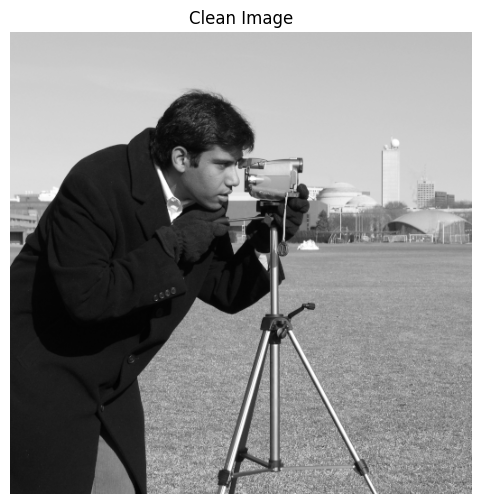

In [4]:
clean_image = data.camera()

inspect_image("clean_image", clean_image)
show_gray(clean_image, "Clean Image", OUTPUT_DIR / "01_clean_image.png")

## 4. 建立含雜訊影像

這裡使用兩種雜訊：

| Noise type | 看起來像什麼 | 常見問題 |
|---|---|---|
| Gaussian noise | 隨機亮度波動 | 整張圖變髒 |
| Salt-and-pepper noise | 隨機黑白點 | 出現孤立極端 pixel |

重點是：不同雜訊類型不應該永遠用同一種預設方法處理。

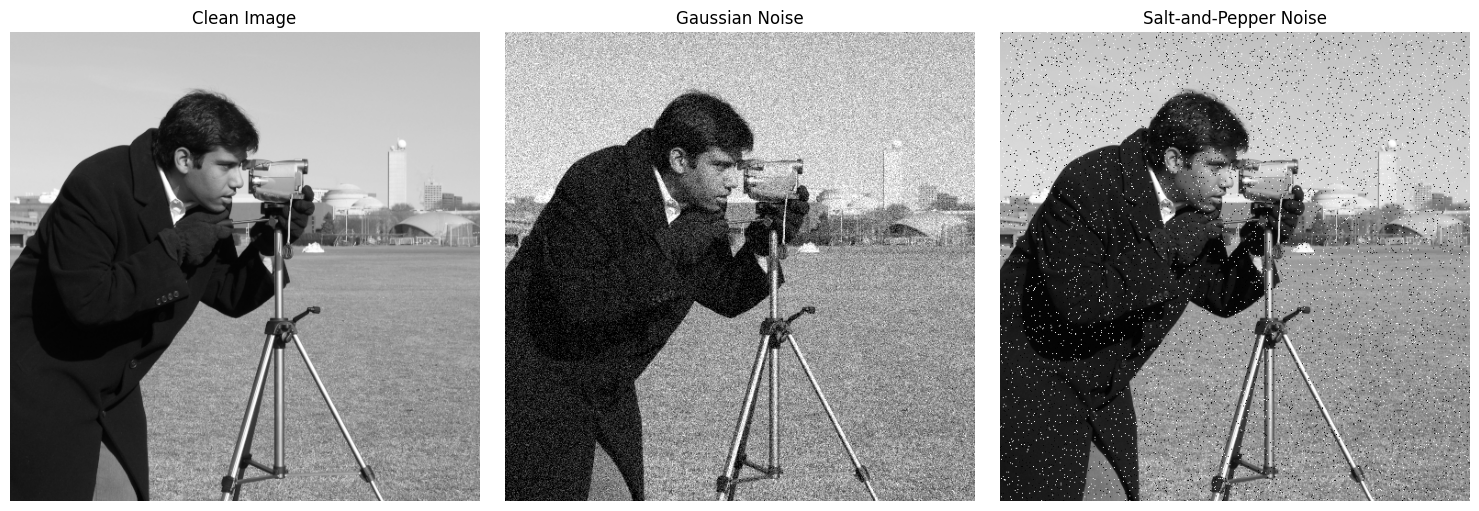

True

In [5]:
def add_gaussian_noise(image, mean=0, std=25):
    """加入 Gaussian noise，並把結果限制在 uint8 範圍。"""
    noise = rng.normal(mean, std, image.shape)
    noisy = image.astype(np.float32) + noise
    noisy = np.clip(noisy, 0, 255)
    return noisy.astype(np.uint8)


def add_salt_pepper_noise(image, amount=0.04, salt_ratio=0.5):
    """在灰階影像中加入 salt-and-pepper noise。"""
    noisy = image.copy()
    total_pixels = image.size

    num_salt = int(total_pixels * amount * salt_ratio)
    num_pepper = int(total_pixels * amount * (1 - salt_ratio))

    salt_coords = (rng.integers(0, image.shape[0], num_salt), rng.integers(0, image.shape[1], num_salt))
    pepper_coords = (rng.integers(0, image.shape[0], num_pepper), rng.integers(0, image.shape[1], num_pepper))

    noisy[salt_coords] = 255
    noisy[pepper_coords] = 0
    return noisy


gaussian_noisy = add_gaussian_noise(clean_image, std=25)
salt_pepper_noisy = add_salt_pepper_noise(clean_image, amount=0.04)

show_grid(
    [clean_image, gaussian_noisy, salt_pepper_noisy],
    ["Clean Image", "Gaussian Noise", "Salt-and-Pepper Noise"],
    cols=3,
    figsize=(15, 5),
    save_path=OUTPUT_DIR / "02_noisy_images_comparison.png"
)

cv2.imwrite(str(OUTPUT_DIR / "02_gaussian_noise.png"), gaussian_noisy)
cv2.imwrite(str(OUTPUT_DIR / "03_salt_pepper_noise.png"), salt_pepper_noisy)

## 5. Gaussian Blur

Gaussian blur 會用附近 pixels 的加權平均來取代目前 pixel。

中心附近的 pixel 權重較高，距離較遠的 pixel 權重較低。

有用的地方是：

```text
隨機波動會被平均掉
```

代價是：

```text
邊緣與細節也會一起變軟
```

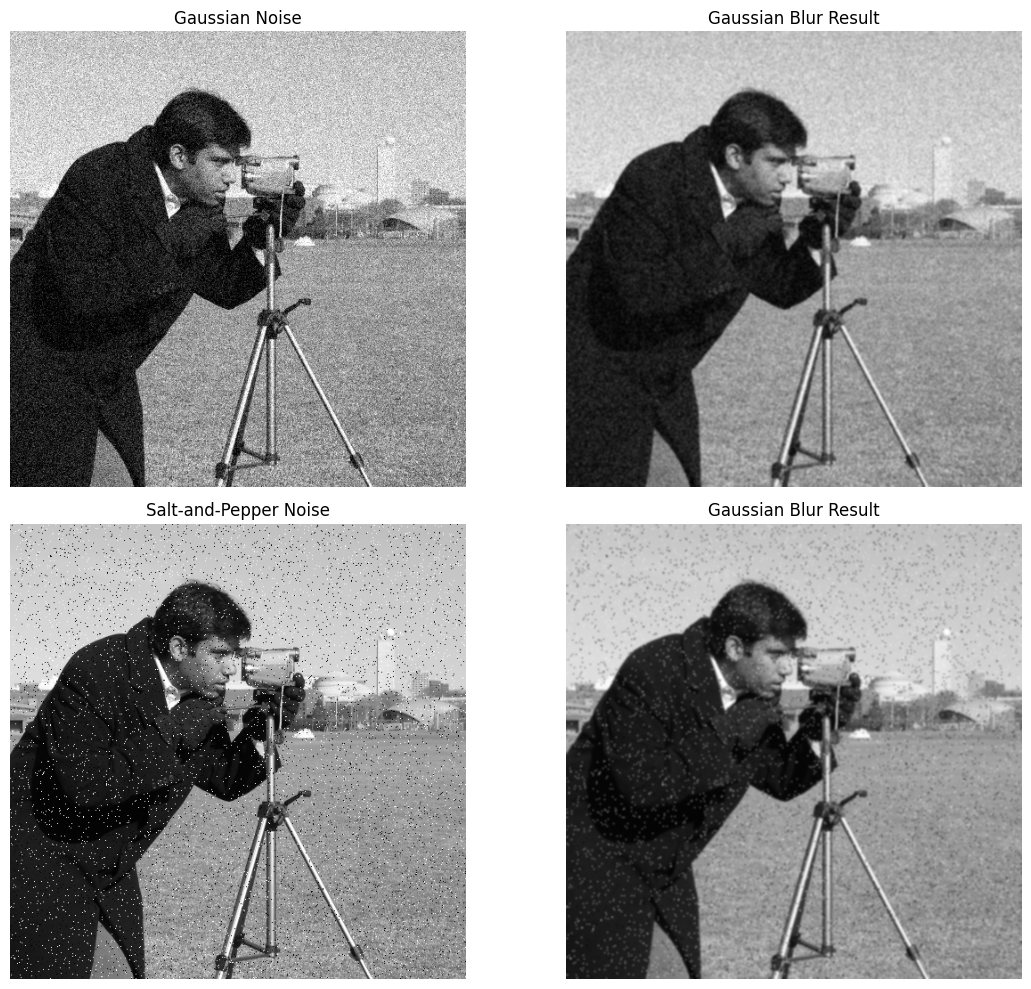

In [6]:
gaussian_from_gaussian_noise = cv2.GaussianBlur(gaussian_noisy, (5, 5), 0)
gaussian_from_sp_noise = cv2.GaussianBlur(salt_pepper_noisy, (5, 5), 0)

show_grid(
    [gaussian_noisy, gaussian_from_gaussian_noise, salt_pepper_noisy, gaussian_from_sp_noise],
    ["Gaussian Noise", "Gaussian Blur Result", "Salt-and-Pepper Noise", "Gaussian Blur Result"],
    cols=2,
    figsize=(12, 10)
)

## 6. Median Filter

Median filter 不是算平均。

它會把鄰域內的 pixel 值排序後取中間值。

這個細節很重要，因為 salt-and-pepper noise 是由 0 和 255 這種極端值構成。中位數比平均值更容易把這些極端點排除掉。

代價是：如果 kernel 太大，小型細節也可能被移除。

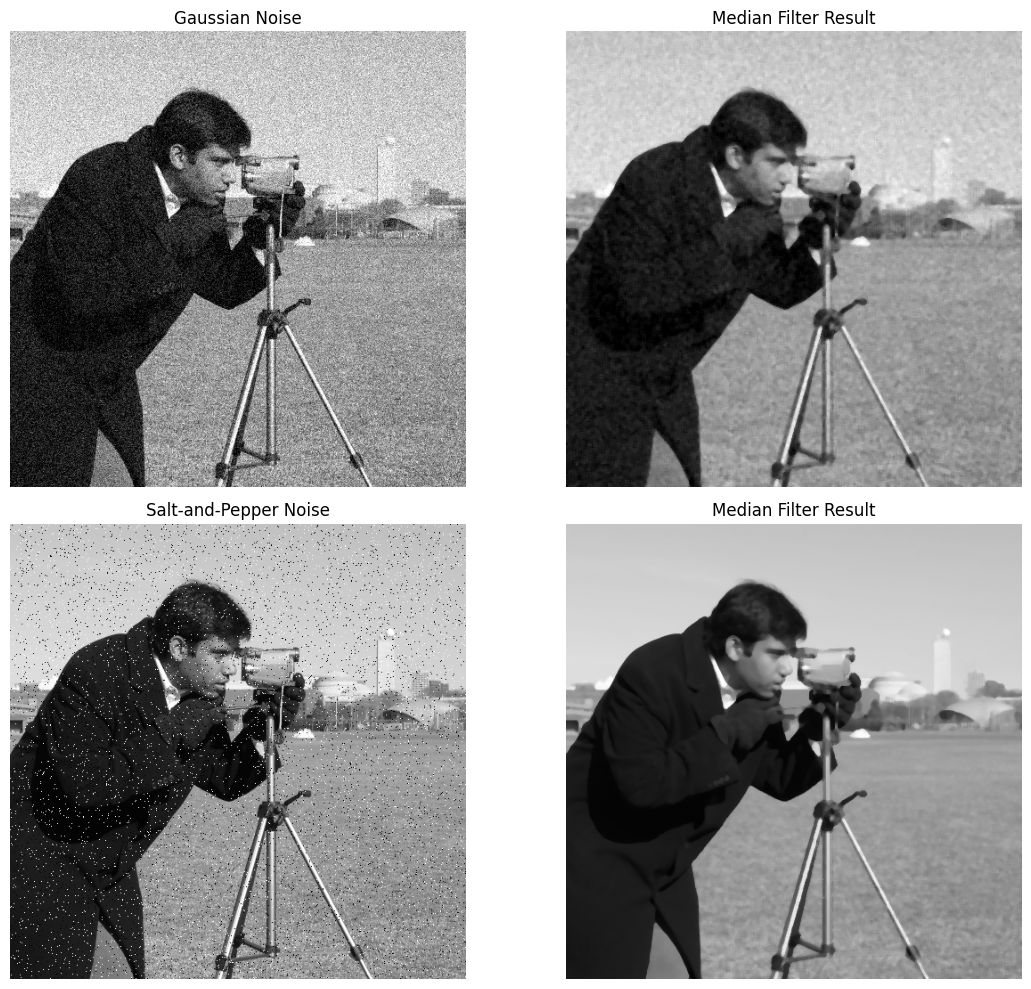

In [7]:
median_from_gaussian_noise = cv2.medianBlur(gaussian_noisy, 5)
median_from_sp_noise = cv2.medianBlur(salt_pepper_noisy, 5)

show_grid(
    [gaussian_noisy, median_from_gaussian_noise, salt_pepper_noisy, median_from_sp_noise],
    ["Gaussian Noise", "Median Filter Result", "Salt-and-Pepper Noise", "Median Filter Result"],
    cols=2,
    figsize=(12, 10)
)

## 7. Bilateral Filter

Bilateral filtering 嘗試在降噪的同時保留邊緣。

它同時考慮兩件事：

- 空間距離：越近的 pixel 影響越大
- 強度差異：越相似的 pixel 影響越大

實際意義是：

```text
在相似區域內平滑，避免跨過強邊緣做平均
```

代價是計算成本較高，而且參數需要調整。

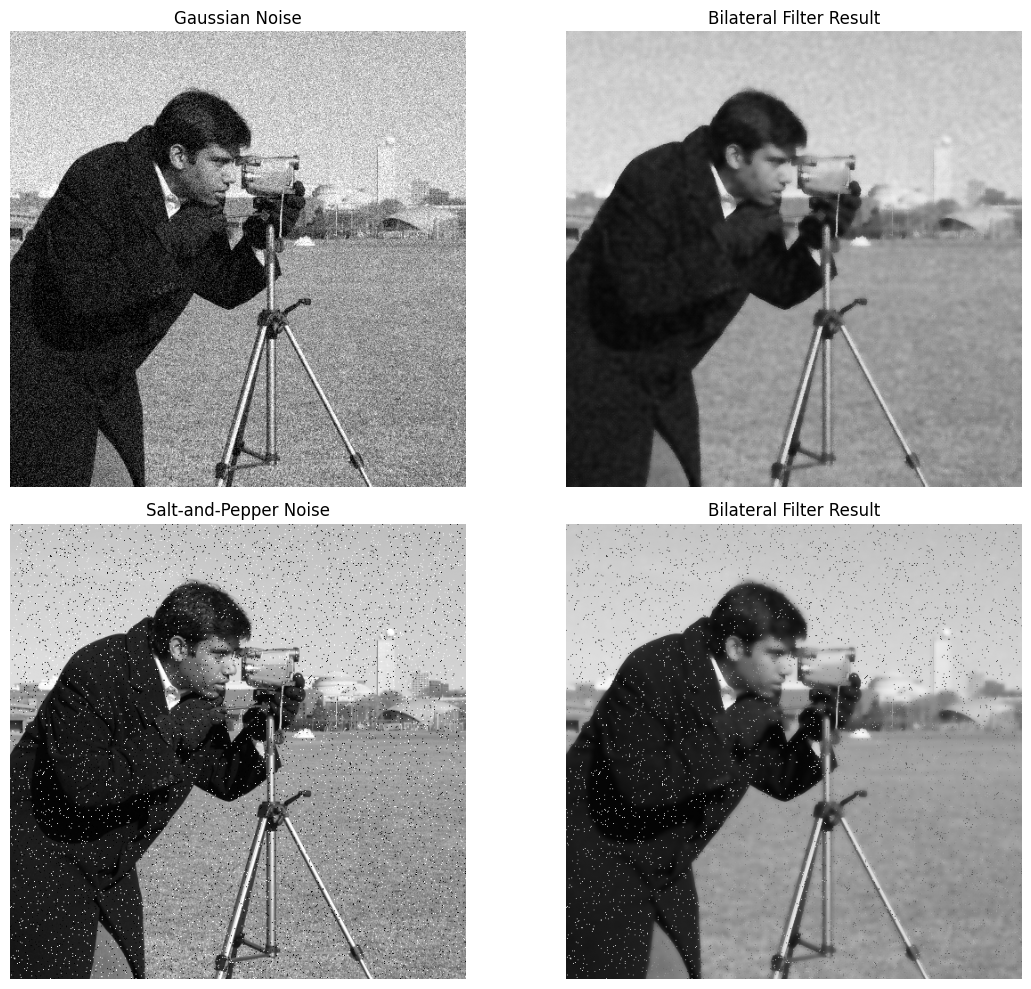

In [8]:
bilateral_from_gaussian_noise = cv2.bilateralFilter(gaussian_noisy, d=9, sigmaColor=75, sigmaSpace=75)
bilateral_from_sp_noise = cv2.bilateralFilter(salt_pepper_noisy, d=9, sigmaColor=75, sigmaSpace=75)

show_grid(
    [gaussian_noisy, bilateral_from_gaussian_noise, salt_pepper_noisy, bilateral_from_sp_noise],
    ["Gaussian Noise", "Bilateral Filter Result", "Salt-and-Pepper Noise", "Bilateral Filter Result"],
    cols=2,
    figsize=(12, 10)
)

## 8. 並排比較

單張結果圖不夠。Filtering 的重點是取捨，所以比較圖要同時看出降噪效果與細節破壞。

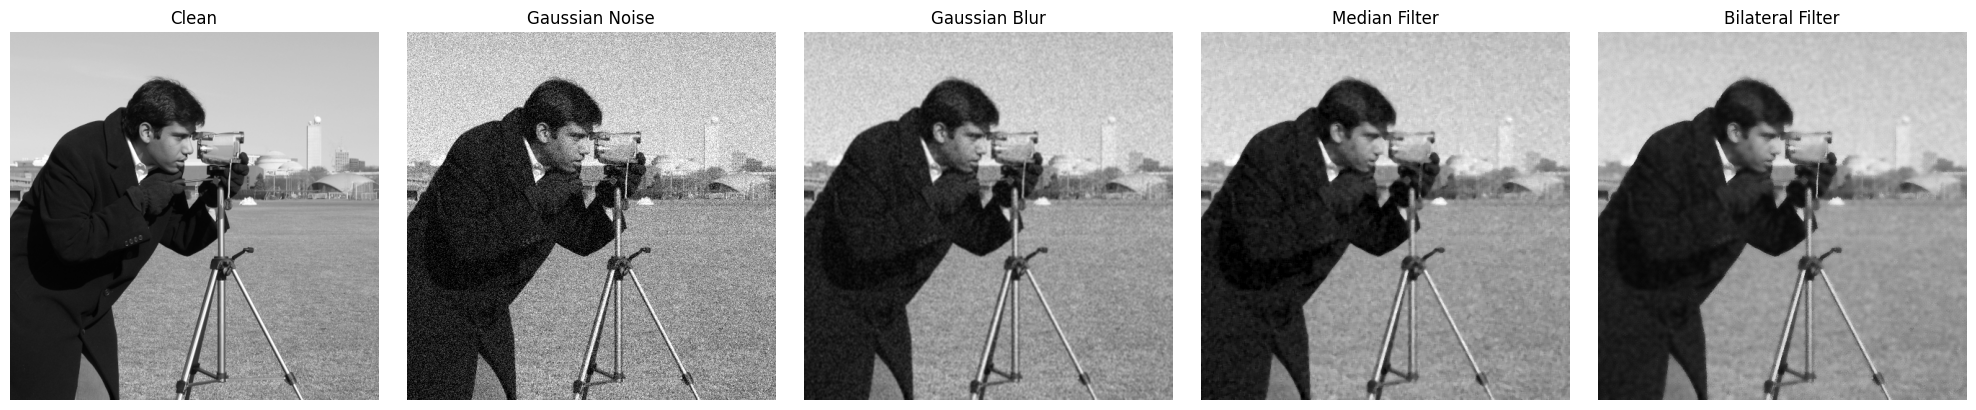

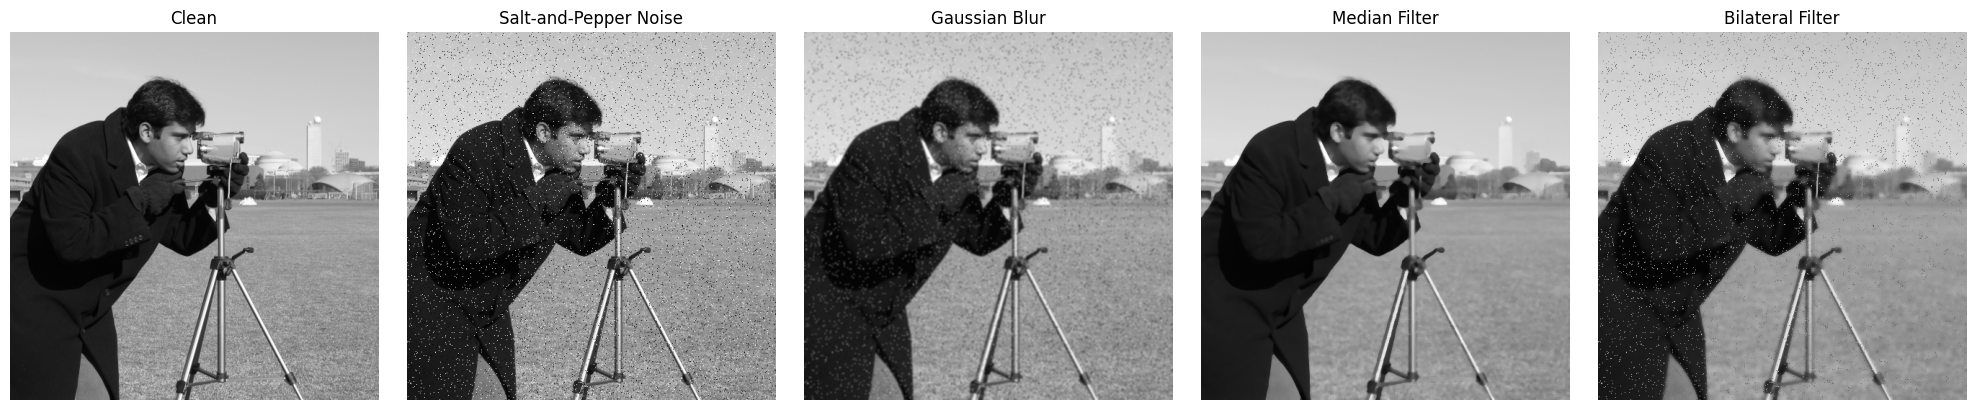

In [9]:
gaussian_results = [
    clean_image,
    gaussian_noisy,
    gaussian_from_gaussian_noise,
    median_from_gaussian_noise,
    bilateral_from_gaussian_noise,
]

gaussian_titles = [
    "Clean",
    "Gaussian Noise",
    "Gaussian Blur",
    "Median Filter",
    "Bilateral Filter",
]

show_grid(
    gaussian_results,
    gaussian_titles,
    cols=5,
    figsize=(20, 4),
    save_path=OUTPUT_DIR / "04_gaussian_noise_filter_comparison.png"
)

sp_results = [
    clean_image,
    salt_pepper_noisy,
    gaussian_from_sp_noise,
    median_from_sp_noise,
    bilateral_from_sp_noise,
]

sp_titles = [
    "Clean",
    "Salt-and-Pepper Noise",
    "Gaussian Blur",
    "Median Filter",
    "Bilateral Filter",
]

show_grid(
    sp_results,
    sp_titles,
    cols=5,
    figsize=(20, 4),
    save_path=OUTPUT_DIR / "05_salt_pepper_filter_comparison.png"
)

## 9. 局部放大比較

完整影像有時候會掩蓋小細節的破壞。

局部 crop 可以更清楚看出邊緣變軟、細節被抹掉等問題。

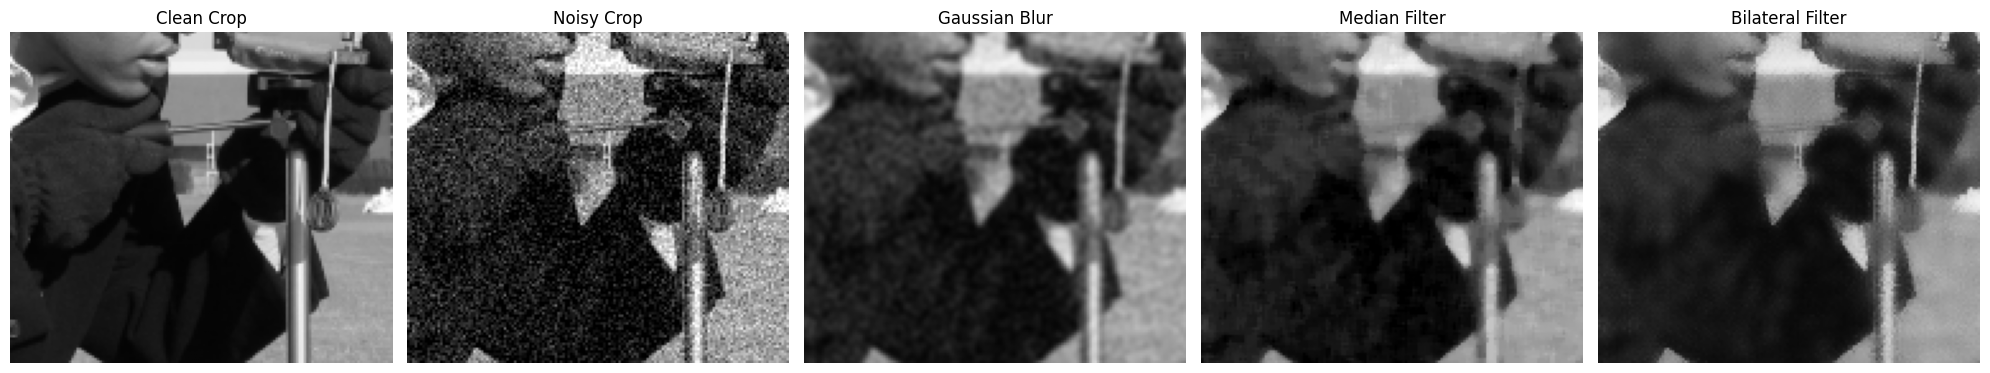

In [10]:
# 擷取包含臉部與邊緣細節的區域。
y1, y2 = 170, 300
x1, x2 = 180, 330

zoom_images = [
    clean_image[y1:y2, x1:x2],
    gaussian_noisy[y1:y2, x1:x2],
    gaussian_from_gaussian_noise[y1:y2, x1:x2],
    median_from_gaussian_noise[y1:y2, x1:x2],
    bilateral_from_gaussian_noise[y1:y2, x1:x2],
]

show_grid(
    zoom_images,
    ["Clean Crop", "Noisy Crop", "Gaussian Blur", "Median Filter", "Bilateral Filter"],
    cols=5,
    figsize=(20, 4),
    save_path=OUTPUT_DIR / "06_zoomed_edge_comparison.png"
)

## 10. 差異圖

Difference map 可以看出處理結果與 clean image 的差異。

越亮代表與原圖差異越大。

這不是完美的品質指標，但很適合用來除錯與觀察方法差異。

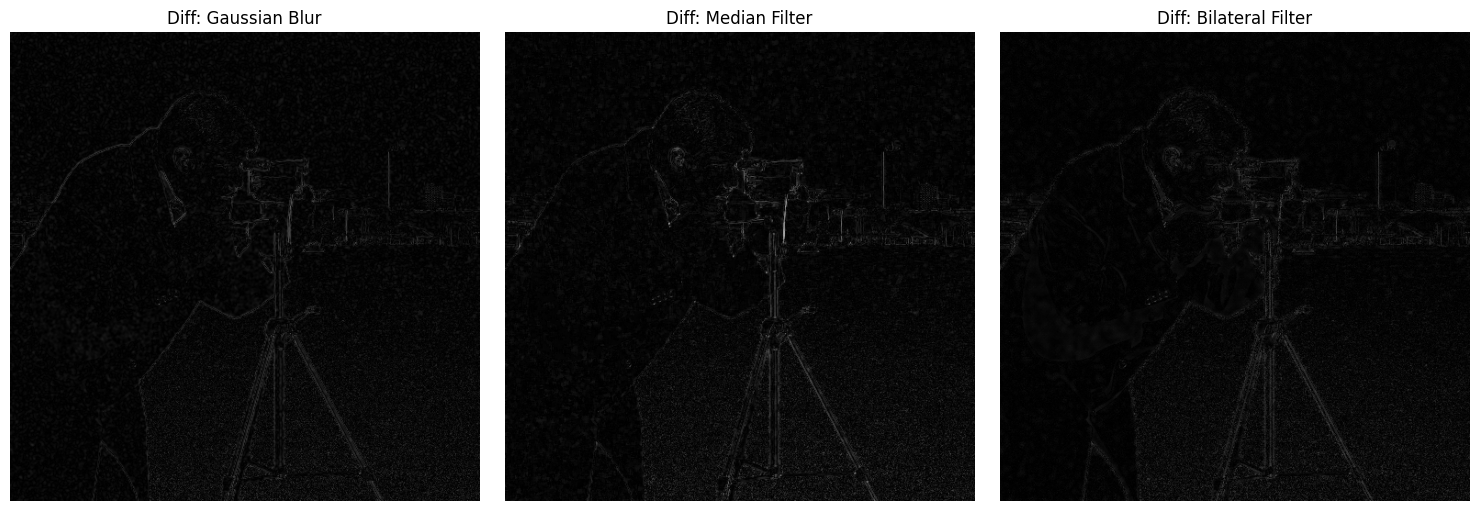

In [11]:
def absolute_difference(reference, image):
    """回傳兩張影像的絕對差異圖。"""
    diff = cv2.absdiff(reference, image)
    return diff


diff_gaussian = absolute_difference(clean_image, gaussian_from_gaussian_noise)
diff_median = absolute_difference(clean_image, median_from_gaussian_noise)
diff_bilateral = absolute_difference(clean_image, bilateral_from_gaussian_noise)

show_grid(
    [diff_gaussian, diff_median, diff_bilateral],
    ["Diff: Gaussian Blur", "Diff: Median Filter", "Diff: Bilateral Filter"],
    cols=3,
    figsize=(15, 5),
    save_path=OUTPUT_DIR / "07_difference_maps.png"
)

## 11. 簡單數值檢查：PSNR

PSNR 不是完整的視覺品質指標，但在有 clean reference 的情況下，可以快速比較處理結果與原圖的接近程度。

PSNR 越高，通常代表處理結果越接近 reference。

但不要盲目相信它。有些方法數值比較好，但在重要局部區域看起來反而更差。

In [12]:
results = {
    "Gaussian noisy": gaussian_noisy,
    "Gaussian blur on Gaussian noise": gaussian_from_gaussian_noise,
    "Median filter on Gaussian noise": median_from_gaussian_noise,
    "Bilateral filter on Gaussian noise": bilateral_from_gaussian_noise,
    "Salt-pepper noisy": salt_pepper_noisy,
    "Gaussian blur on salt-pepper noise": gaussian_from_sp_noise,
    "Median filter on salt-pepper noise": median_from_sp_noise,
    "Bilateral filter on salt-pepper noise": bilateral_from_sp_noise,
}

for name, result in results.items():
    print(f"{name:40s}: {psnr(clean_image, result):.2f} dB")

Gaussian noisy                          : 20.59 dB
Gaussian blur on Gaussian noise         : 27.19 dB
Median filter on Gaussian noise         : 26.30 dB
Bilateral filter on Gaussian noise      : 27.56 dB
Salt-pepper noisy                       : 18.85 dB
Gaussian blur on salt-pepper noise      : 26.37 dB
Median filter on salt-pepper noise      : 27.89 dB
Bilateral filter on salt-pepper noise   : 22.10 dB


## 12. 參數比較

濾波強度受到參數控制。

越強的濾波通常可以移除更多雜訊，但也更容易破壞細節。這就是基本取捨。

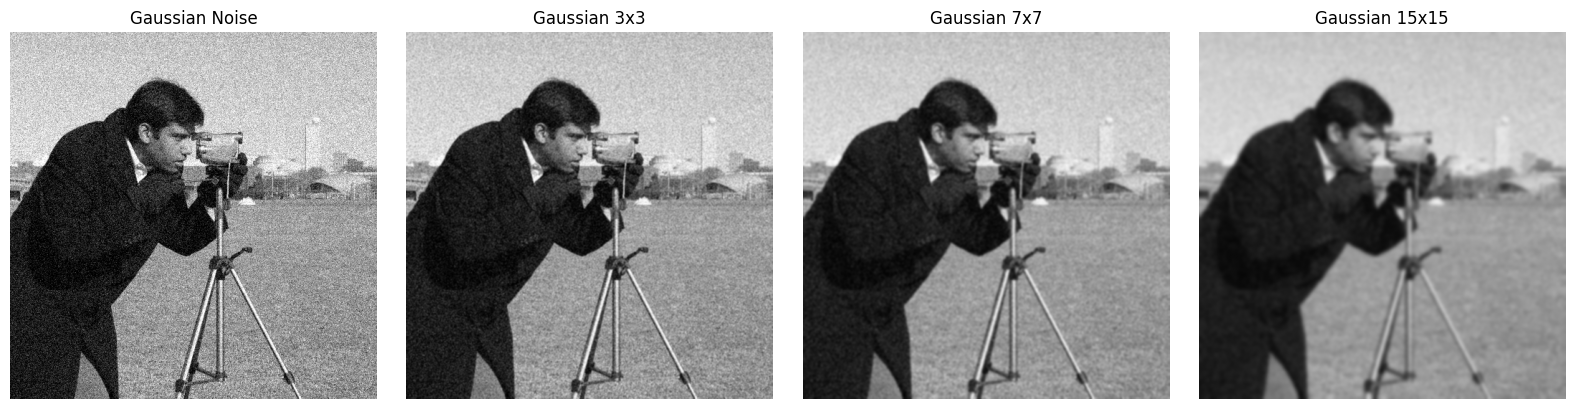

In [13]:
blur_3 = cv2.GaussianBlur(gaussian_noisy, (3, 3), 0)
blur_7 = cv2.GaussianBlur(gaussian_noisy, (7, 7), 0)
blur_15 = cv2.GaussianBlur(gaussian_noisy, (15, 15), 0)

show_grid(
    [gaussian_noisy, blur_3, blur_7, blur_15],
    ["Gaussian Noise", "Gaussian 3x3", "Gaussian 7x7", "Gaussian 15x15"],
    cols=4,
    figsize=(16, 4),
    save_path=OUTPUT_DIR / "08_gaussian_kernel_size_comparison.png"
)

## 13. 保存最終濾波結果

主要比較圖前面已經保存。這裡另外保存個別濾波結果，方便後續檢查或放進 README 截圖。

In [14]:
cv2.imwrite(str(OUTPUT_DIR / "09_gaussian_blur_on_gaussian_noise.png"), gaussian_from_gaussian_noise)
cv2.imwrite(str(OUTPUT_DIR / "10_median_filter_on_gaussian_noise.png"), median_from_gaussian_noise)
cv2.imwrite(str(OUTPUT_DIR / "11_bilateral_filter_on_gaussian_noise.png"), bilateral_from_gaussian_noise)
cv2.imwrite(str(OUTPUT_DIR / "12_gaussian_blur_on_salt_pepper_noise.png"), gaussian_from_sp_noise)
cv2.imwrite(str(OUTPUT_DIR / "13_median_filter_on_salt_pepper_noise.png"), median_from_sp_noise)
cv2.imwrite(str(OUTPUT_DIR / "14_bilateral_filter_on_salt_pepper_noise.png"), bilateral_from_sp_noise)

print("已儲存輸出檔案：")
for path in sorted(OUTPUT_DIR.glob("*.png")):
    print(path)

已儲存輸出檔案：
outputs/02_filtering_and_denoising/01_clean_image.png
outputs/02_filtering_and_denoising/02_gaussian_noise.png
outputs/02_filtering_and_denoising/02_noisy_images_comparison.png
outputs/02_filtering_and_denoising/03_salt_pepper_noise.png
outputs/02_filtering_and_denoising/04_gaussian_noise_filter_comparison.png
outputs/02_filtering_and_denoising/05_salt_pepper_filter_comparison.png
outputs/02_filtering_and_denoising/06_zoomed_edge_comparison.png
outputs/02_filtering_and_denoising/07_difference_maps.png
outputs/02_filtering_and_denoising/08_gaussian_kernel_size_comparison.png
outputs/02_filtering_and_denoising/09_gaussian_blur_on_gaussian_noise.png
outputs/02_filtering_and_denoising/10_median_filter_on_gaussian_noise.png
outputs/02_filtering_and_denoising/11_bilateral_filter_on_gaussian_noise.png
outputs/02_filtering_and_denoising/12_gaussian_blur_on_salt_pepper_noise.png
outputs/02_filtering_and_denoising/13_median_filter_on_salt_pepper_noise.png
outputs/02_filtering_and_denois

## 14. 工程筆記

- Gaussian blur 本質上是平均，所以能降低隨機波動，但會讓邊緣變軟。
- Median filter 不是平均，所以特別適合處理孤立的極端黑白點。
- Bilateral filter 嘗試在區域內平滑，同時保留強邊緣，但計算成本與參數調整成本較高。
- 不同雜訊類型需要不同 filter。
- 全圖看起來不錯，不代表重要局部細節沒有被破壞。
- 比較時至少要看原圖、雜訊圖、濾波結果、局部放大與差異圖。

## 15. 下一步

下一份 notebook：

```text
../03_thresholding/thresholding.ipynb
```

中文版：

```text
../03_thresholding/thresholding_zh.ipynb
```

Filtering 是在準備影像。Thresholding 則開始做第一個硬性判斷：哪些 pixels 屬於目標區域，哪些 pixels 不屬於。